# Backtest & Evaluation — Enhanced Strategies

**OOS period: 2024-01-01 to end of data**

Four strategies compared:
1. **Baseline** — original Z-score (±2 entry, 0 exit)
2. **Baseline + Risk Controls** — adds stop-loss (|z|>3.5) and cointegration gate (rolling ADF p<0.10)
3. **ML fixed model** — original ML with single IS-trained model
4. **ML walk-forward + Risk Controls** — model retrained every 6 months on expanding data,
   plus stop-loss, cointegration gate, and VIX filter (no new entries when VIX≥25)

All enhancement parameters are pre-specified from economic reasoning — not tuned on OOS data.
Transaction costs: 5 bps per leg (10 bps round-trip).

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
import yfinance as yf
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
sys.path.append('..')
from src.utils import sharpe_ratio, max_drawdown

In [2]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
IS_END          = '2023-12-31'
OOS_START       = '2024-01-01'
ENTRY_Z         = 2.0
EXIT_Z          = 0.0
PROBA_THRESHOLD = 0.55
COST_PER_LEG    = 0.0005   # 5 bps per leg → 10 bps round-trip

# Enhancement parameters — chosen from domain knowledge, not OOS grid-search
STOP_Z   = 3.5    # exit trade if z moves 1.5σ beyond entry (runaway spread)
ADF_GATE = 0.10   # skip entry if rolling ADF p-value ≥ this (cointegration gone)
VIX_GATE = 25.0   # skip ML entries during high-vol/trending regime

ML_FEATURES = [
    'z_score', 'spread_change', 'spread_vol_20',
    'adf_p_252', 'hurst_252', 'adf_stationary', 'hurst_mr', 'regime_score',
]

# Walk-forward windows: (train through, predict start, predict end)
WF_WINDOWS = [
    ('2023-12-31', '2024-01-01', '2024-06-30'),
    ('2024-06-30', '2024-07-01', '2024-12-31'),
    ('2024-12-31', '2025-01-01', '2025-06-30'),
    ('2025-06-30', '2025-07-01', '2026-12-31'),
]
# ────────────────────────────────────────────────────────────────────────────

In [3]:
# ── POSITION FUNCTIONS ───────────────────────────────────────────────────────

def compute_positions(z, entry_z, exit_z):
    '''Baseline: enter on z-threshold, exit when z crosses 0.'''
    pos, cur = np.zeros(len(z)), 0
    for i, zi in enumerate(z.values):
        if cur == 0:
            if zi < -entry_z:   cur =  1
            elif zi > entry_z:  cur = -1
        elif cur == 1:
            if zi >= exit_z:    cur =  0
        else:
            if zi <= -exit_z:   cur =  0
        pos[i] = cur
    return pd.Series(pos, index=z.index)


def compute_positions_enhanced(z, adf_p, entry_z, exit_z, stop_z, adf_gate):
    '''Baseline + cointegration gate + stop-loss.
    Gate: only enter if rolling ADF p-value < adf_gate (spread still stationary).
    Stop-loss: exit when z moves stop_z past our entry direction (runaway spread).
    '''
    pos, cur = np.zeros(len(z)), 0
    for i in range(len(z)):
        zi, adf_i = z.values[i], adf_p.values[i]
        if cur == 0:
            coint_ok = not (np.isnan(adf_i) or adf_i >= adf_gate)
            if coint_ok:
                if zi < -entry_z:   cur =  1
                elif zi > entry_z:  cur = -1
        elif cur == 1:
            # Exit on reversion OR stop-loss (spread moved further negative than stop_z)
            if zi >= exit_z or zi < -stop_z:   cur = 0
        else:
            if zi <= -exit_z or zi > stop_z:   cur = 0
        pos[i] = cur
    return pd.Series(pos, index=z.index)


def compute_ml_positions(z, proba, entry_z, exit_z, proba_threshold):
    '''Original ML: ML gates entry, exit on z crossing 0.'''
    pos, cur = np.zeros(len(z)), 0
    for i in range(len(z)):
        zi, pi = z.values[i], proba.values[i]
        if cur == 0:
            if zi < -entry_z and pi > proba_threshold:   cur =  1
            elif zi > entry_z and pi > proba_threshold:  cur = -1
        elif cur == 1:
            if zi >= exit_z:   cur = 0
        else:
            if zi <= -exit_z:  cur = 0
        pos[i] = cur
    return pd.Series(pos, index=z.index)


def compute_ml_positions_enhanced(z, proba, adf_p, vix_aligned,
                                   entry_z, exit_z, stop_z,
                                   proba_threshold, adf_gate, vix_gate):
    '''Walk-forward ML + cointegration gate + VIX regime filter + stop-loss.'''
    pos, cur = np.zeros(len(z)), 0
    vix_vals = vix_aligned.values
    for i in range(len(z)):
        zi, pi = z.values[i], proba.values[i]
        adf_i, vix_i = adf_p.values[i], vix_vals[i]
        if cur == 0:
            coint_ok = not (np.isnan(adf_i) or adf_i >= adf_gate)
            vix_ok   = np.isnan(vix_i) or vix_i < vix_gate
            if coint_ok and vix_ok:
                if zi < -entry_z and pi > proba_threshold:   cur =  1
                elif zi > entry_z and pi > proba_threshold:  cur = -1
        elif cur == 1:
            if zi >= exit_z or zi < -stop_z:  cur = 0
        else:
            if zi <= -exit_z or zi > stop_z:  cur = 0
        pos[i] = cur
    return pd.Series(pos, index=z.index)


def get_trade_returns(pos, daily_ret):
    active    = pos.shift(1).fillna(0) != 0
    if not active.any():
        return []
    new_trade = active & (~active.shift(1).fillna(False))
    tid       = new_trade.cumsum()
    tid[~active] = 0
    return [daily_ret[tid == t].sum() for t in sorted(tid[tid > 0].unique())]

In [4]:
# ── VIX data ─────────────────────────────────────────────────────────────────
vix_raw = yf.download('^VIX', start='2020-01-01', end='2026-01-01',
                      auto_adjust=True, progress=False)
vix = vix_raw['Close'].squeeze()
vix.index.name = 'Date'

oos_vix = vix.loc[OOS_START:]
print(f'VIX OOS ({OOS_START} onward): mean={oos_vix.mean():.1f}, '
      f'max={oos_vix.max():.1f}, '
      f'days above {VIX_GATE}: {(oos_vix >= VIX_GATE).sum()}')

VIX OOS (2024-01-01 onward): mean=17.3, max=52.3, days above 25.0: 24


In [5]:
# ── WALK-FORWARD ML ───────────────────────────────────────────────────────────
def walk_forward_proba(dataset):
    '''Retrain LogisticRegression every 6 months on expanding IS window.
    Returns a Series of OOS probabilities for the full 2024-2025 period.
    Ensures no data from future prediction window leaks into training.
    '''
    X, y = dataset[ML_FEATURES].copy(), dataset['y'].copy()
    segs = []
    for train_end, pred_start, pred_end in WF_WINDOWS:
        X_tr = X.loc[:train_end]
        y_tr = y.loc[:train_end]
        X_pr = X.loc[pred_start:pred_end]
        if len(X_pr) == 0 or len(y_tr) < 100:
            continue
        m = Pipeline([('s', StandardScaler()),
                      ('lr', LogisticRegression(max_iter=2000, C=0.1))])
        m.fit(X_tr, y_tr)
        segs.append(pd.Series(m.predict_proba(X_pr)[:, 1], index=X_pr.index))
    return pd.concat(segs).sort_index() if segs else pd.Series(dtype=float)

In [6]:
# ── LOAD DATA + COMPUTE ALL STRATEGIES PER PAIR ───────────────────────────────
selected_pairs = pd.read_csv('../data_processed/selected_pairs.csv', index_col=0)
pair_data = {}

for _, row in selected_pairs.iterrows():
    t1, t2 = row['ticker1'], row['ticker2']
    key    = f'{t1}/{t2}'

    feats   = pd.read_csv(f'../data_processed/features_{t1}_{t2}.csv',
                          index_col=0, parse_dates=True)
    preds   = pd.read_csv(f'../data_processed/predictions_{t1}_{t2}.csv',
                          index_col=0, parse_dates=True)
    dataset = pd.read_csv(f'../data_processed/dataset_{t1}_{t2}.csv',
                          index_col=0, parse_dates=True)

    idx               = feats.index.intersection(preds.index)
    feats, preds      = feats.loc[idx], preds.loc[idx]
    z, sr, adf_p      = feats['z_score'], feats['spread_ret'], feats['adf_p_252']
    proba_fixed       = preds['proba']

    # Align VIX (forward-fill any gaps)
    vix_aligned = vix.reindex(feats.index).ffill()

    # Walk-forward probabilities (OOS only; IS uses fixed model for state warmup)
    wf_oos  = walk_forward_proba(dataset.reindex(feats.index))
    proba_wf = proba_fixed.copy()
    proba_wf.update(wf_oos)

    # Positions over full history (IS warmup → OOS)
    b_pos_full   = compute_positions(z, ENTRY_Z, EXIT_Z)
    be_pos_full  = compute_positions_enhanced(z, adf_p, ENTRY_Z, EXIT_Z, STOP_Z, ADF_GATE)
    ml_pos_full  = compute_ml_positions(z, proba_fixed, ENTRY_Z, EXIT_Z, PROBA_THRESHOLD)
    mle_pos_full = compute_ml_positions_enhanced(
                       z, proba_wf, adf_p, vix_aligned,
                       ENTRY_Z, EXIT_Z, STOP_Z, PROBA_THRESHOLD, ADF_GATE, VIX_GATE)

    # Slice to OOS
    def oos(s): return s.loc[OOS_START:]
    b_pos, be_pos, ml_pos, mle_pos = map(oos, [b_pos_full, be_pos_full,
                                                ml_pos_full, mle_pos_full])
    sr_oos = oos(sr)

    def ret(pos, cost=0.0):
        r = pos.shift(1).fillna(0) * sr_oos
        return r - pos.diff().fillna(0).abs() * cost

    pair_data[key] = {
        'b_pos':  b_pos,  'be_pos':  be_pos,
        'ml_pos': ml_pos, 'mle_pos': mle_pos,
        'b_ret':    ret(b_pos),    'b_ret_c':    ret(b_pos,   COST_PER_LEG),
        'be_ret':   ret(be_pos),   'be_ret_c':   ret(be_pos,  COST_PER_LEG),
        'ml_ret':   ret(ml_pos),   'ml_ret_c':   ret(ml_pos,  COST_PER_LEG),
        'mle_ret':  ret(mle_pos),  'mle_ret_c':  ret(mle_pos, COST_PER_LEG),
    }

print(f'Computed strategies for {len(pair_data)} pairs over OOS period')

Computed strategies for 15 pairs over OOS period


In [7]:
# ── METRICS ──────────────────────────────────────────────────────────────────
def summarize(label, ret_key, pos_key, cost_tag):
    all_ret = pd.concat({k: v[ret_key] for k, v in pair_data.items()}, axis=1).fillna(0)
    port    = all_ret.mean(axis=1)
    eq      = (1 + port).cumprod()

    trades    = []
    for v in pair_data.values():
        trades.extend(get_trade_returns(v[pos_key], v[ret_key]))

    n   = len(trades)
    wr  = float(np.mean([t > 0 for t in trades])) if trades else np.nan
    avg = float(np.mean(trades))                   if trades else np.nan
    return {
        'Strategy':     label,
        'Costs':        cost_tag,
        'Total Return': round(float(eq.iloc[-1] - 1), 4),
        'Sharpe':       round(sharpe_ratio(port), 3),
        'Max DD':       round(max_drawdown(eq), 4),
        'Trades':       n,
        'Win Rate':     round(wr,  3) if not np.isnan(wr)  else np.nan,
        'Avg Trade':    round(avg, 5) if not np.isnan(avg) else np.nan,
    }

results = pd.DataFrame([
    summarize('1. Baseline',            'b_ret',    'b_pos',   'None'),
    summarize('1. Baseline',            'b_ret_c',  'b_pos',   '10 bps RT'),
    summarize('2. Baseline + RC',       'be_ret',   'be_pos',  'None'),
    summarize('2. Baseline + RC',       'be_ret_c', 'be_pos',  '10 bps RT'),
    summarize('3. ML fixed',            'ml_ret',   'ml_pos',  'None'),
    summarize('3. ML fixed',            'ml_ret_c', 'ml_pos',  '10 bps RT'),
    summarize('4. ML walk-fwd + RC',    'mle_ret',  'mle_pos', 'None'),
    summarize('4. ML walk-fwd + RC',    'mle_ret_c','mle_pos', '10 bps RT'),
])

print('\n=== OOS Performance (2024-2025) ===\n')
pd.set_option('display.width', 120)
print(results.to_string(index=False))


=== OOS Performance (2024-2025) ===

           Strategy     Costs  Total Return  Sharpe  Max DD  Trades  Win Rate  Avg Trade
        1. Baseline      None       -0.2081  -1.097 -0.2493      39     0.615   -0.08573
        1. Baseline 10 bps RT       -0.2097  -1.107 -0.2503      39     0.615   -0.08608
   2. Baseline + RC      None       -0.0535  -0.686 -0.1123      22     0.545   -0.03643
   2. Baseline + RC 10 bps RT       -0.0546  -0.701 -0.1126      22     0.545   -0.03684
        3. ML fixed      None       -0.2013  -1.071 -0.2499      35     0.571   -0.09202
        3. ML fixed 10 bps RT       -0.2028  -1.080 -0.2507      35     0.571   -0.09236
4. ML walk-fwd + RC      None        0.0154   0.997 -0.0068       7     1.000    0.03278
4. ML walk-fwd + RC 10 bps RT        0.0150   0.974 -0.0069       7     1.000    0.03235


/var/folders/3g/lbd99xz94p179sd0d5kgsb6r0000gp/T/ipykernel_71298/1302909314.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_trade = active & (~active.shift(1).fillna(False))
/var/folders/3g/lbd99xz94p179sd0d5kgsb6r0000gp/T/ipykernel_71298/1302909314.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_trade = active & (~active.shift(1).fillna(False))
/var/folders/3g/lbd99xz94p179sd0d5kgsb6r0000gp/T/ipykernel_71298/1302909314.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a fu

In [8]:
# ── PER-PAIR TRADE COUNTS ─────────────────────────────────────────────────────
tc = pd.DataFrame([{
    'Pair':       key,
    'Baseline':   len(get_trade_returns(v['b_pos'],   v['b_ret'])),
    '+RC':        len(get_trade_returns(v['be_pos'],  v['be_ret'])),
    'ML fixed':   len(get_trade_returns(v['ml_pos'],  v['ml_ret'])),
    'ML WF+RC':   len(get_trade_returns(v['mle_pos'], v['mle_ret'])),
} for key, v in pair_data.items()])

print(tc.to_string(index=False))
print(f"\nTotals: Baseline={tc['Baseline'].sum()} | +RC={tc['+RC'].sum()} | "
      f"ML fixed={tc['ML fixed'].sum()} | ML WF+RC={tc['ML WF+RC'].sum()}")

    Pair  Baseline  +RC  ML fixed  ML WF+RC
 EWJ/HYG         3    2         3         1
 HYG/XLC         1    0         1         0
 XLU/XOP         1    1         1         0
HYG/MTUM         3    2         3         1
 EWC/IWD         4    5         2         0
GDXJ/LQD         3    2         3         0
 USO/XLU         1    1         1         0
 EWG/HYG         2    0         2         0
 EWJ/XLC         6    4         4         3
 EWC/XLF         3    0         3         0
GDXJ/USO         1    1         1         0
 XLP/XLV         3    0         3         0
 XLP/XLU         3    3         3         1
 EWA/XLB         3    1         3         1
 GDX/USO         2    0         2         0

Totals: Baseline=39 | +RC=22 | ML fixed=35 | ML WF+RC=7


/var/folders/3g/lbd99xz94p179sd0d5kgsb6r0000gp/T/ipykernel_71298/1302909314.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_trade = active & (~active.shift(1).fillna(False))
/var/folders/3g/lbd99xz94p179sd0d5kgsb6r0000gp/T/ipykernel_71298/1302909314.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_trade = active & (~active.shift(1).fillna(False))
/var/folders/3g/lbd99xz94p179sd0d5kgsb6r0000gp/T/ipykernel_71298/1302909314.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a fu

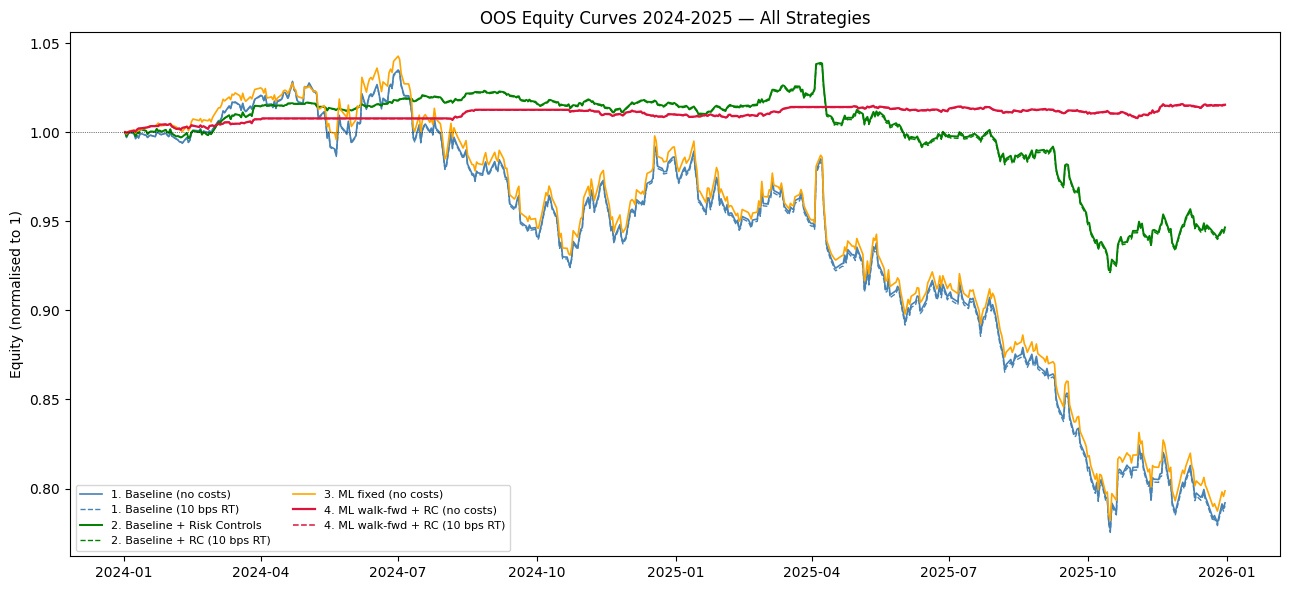

Saved oos_results_enhanced.png


In [9]:
# ── EQUITY CURVES ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

for ret_key, label, color, ls, lw in [
    ('b_ret',    '1. Baseline (no costs)',         'steelblue',  '-',  1.2),
    ('b_ret_c',  '1. Baseline (10 bps RT)',         'steelblue',  '--', 1.0),
    ('be_ret',   '2. Baseline + Risk Controls',     'green',      '-',  1.4),
    ('be_ret_c', '2. Baseline + RC (10 bps RT)',    'green',      '--', 1.0),
    ('ml_ret',   '3. ML fixed (no costs)',          'orange',     '-',  1.2),
    ('mle_ret',  '4. ML walk-fwd + RC (no costs)', 'crimson',    '-',  1.6),
    ('mle_ret_c','4. ML walk-fwd + RC (10 bps RT)','crimson',    '--', 1.1),
]:
    port = pd.concat({k: v[ret_key] for k, v in pair_data.items()},
                     axis=1).fillna(0).mean(axis=1)
    eq = (1 + port).cumprod()
    ax.plot(eq.index, eq.values, label=label, color=color, ls=ls, lw=lw)

ax.axhline(1, color='black', lw=0.5, ls=':')
ax.set_title('OOS Equity Curves 2024-2025 — All Strategies', fontsize=12)
ax.set_ylabel('Equity (normalised to 1)')
ax.legend(fontsize=8, ncol=2, loc='lower left')
plt.tight_layout()
plt.savefig('../data_processed/oos_results_enhanced.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved oos_results_enhanced.png')